# Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from keras.layers import Dense
from sklearn.preprocessing import StandardScaler
import time

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [2]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(census_filename)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

1. I chose the census dataset.
2. My label is income_binary. I am predict whether someone has high income or low income.
3. The features I plan to use are hours-per-week, education-num, work-class, age, occupation
4. This problem matters because this information could by use to decide who gets government assistance, such a healthcare or food stamps.

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

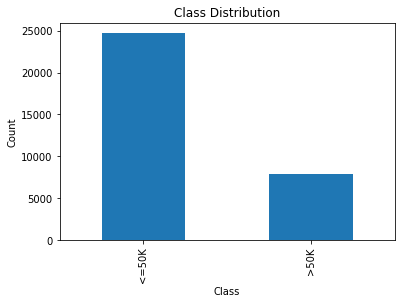

In [3]:
# YOUR CODE HERE
df.describe()
df['income_binary'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  32399.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.589216  1.897784e+05      10.080679    615.907773     87.303830   
std       13.647862  1.055500e+05       2.572720   2420.191974    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  14084.000000   4356.000000   

       hours-per-week  
count    32236.000000  
mean        40.450428  
std         12.353748  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


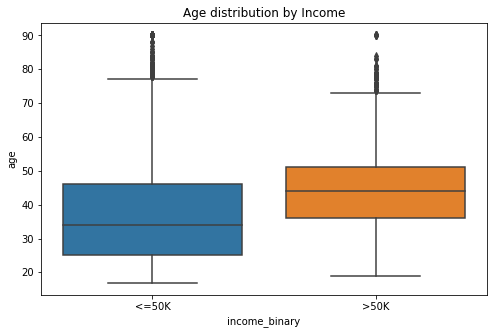

In [4]:
# YOUR CODE HERE
print(df.describe())

plt.figure(figsize=(8,5))
sns.boxplot(x='income_binary', y='age', data=df)
plt.title('Age distribution by Income')
plt.show()

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

The dataset is imbalanced, with significantly more individuals earning <=50K than >50K. The age distribution also shows that individuals earning <=50K tend to be younger, with most falling between approximately 25 and 45 years old. During data preparation, I will first handle any missing values. I will then apply one-hot encoding to convert categorical features into numerical features for machine learning models.

### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

1. This dataset contains more people who earn less than $50K than people who earn more, which creates class imbalance. It also includes features such as age, race, sex, and marital status, which could introduce bias if the model relies too heavily on them when making predictions.

2. People could be harmed if the model makes incorrect predictions and is used to make decisions about jobs, loans, or government assistance. Some groups may also be affected more than others if the model performs better on the groups that are more represented in the dataset.

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [5]:
# Determine columns with missing data
nan_count = np.sum(df.isnull(), axis = 0)
print(nan_count)

condition = nan_count != 0 # look for all columns with missing values

col_names = nan_count[condition].index # get the column names
print(col_names)

nan_cols = list(col_names) # convert column names to list
print(nan_cols)

age                162
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex_selfID           0
capital-gain         0
capital-loss         0
hours-per-week     325
native-country     583
income_binary        0
dtype: int64
Index(['age', 'workclass', 'occupation', 'hours-per-week', 'native-country'], dtype='object')
['age', 'workclass', 'occupation', 'hours-per-week', 'native-country']


In [6]:
# Fill null values in numerical columns with mean
mean_hours = df['hours-per-week'].mean()
df['hours-per-week'].fillna(value=mean_hours, inplace=True)

mean_age = df['age'].mean()
df['age'].fillna(value=mean_age, inplace=True)

# Fill null values in categorical with 'Unknown'
df['workclass'].fillna(value='Unknown', inplace=True)
df['occupation'].fillna(value='Unknown', inplace=True)
df['native-country'].fillna(value='Unknown', inplace=True)

In [7]:
# Check if there are any null values left
print(np.sum(df['age'].isnull(), axis = 0))
print(np.sum(df['workclass'].isnull(), axis = 0))
print(np.sum(df['hours-per-week'].isnull(), axis = 0))
print(np.sum(df['occupation'].isnull(), axis = 0))
print(np.sum(df['native-country'].isnull(), axis = 0))

0
0
0
0
0


In [8]:
# Applying One Hot Encoding
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('income_binary')

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)
print(df.shape)
print(df.head())

(32561, 101)
    age  fnlwgt  education-num  capital-gain  capital-loss  hours-per-week  \
0  39.0   77516             13          2174             0            40.0   
1  50.0   83311             13             0             0            13.0   
2  38.0  215646              9             0             0            40.0   
3  53.0  234721              7             0             0            40.0   
4  28.0  338409             13             0             0            40.0   

  income_binary  workclass_Local-gov  workclass_Never-worked  \
0         <=50K                    0                       0   
1         <=50K                    0                       0   
2         <=50K                    0                       0   
3         <=50K                    0                       0   
4         <=50K                    0                       0   

   workclass_Private  ...  native-country_Puerto-Rico  \
0                  0  ...                           0   
1                  

### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

I filled the missing values in the numerical columns with the mean because it is a common method that preserves the overall distribution of the data when only a small percentage of values are missing. For the categorical columns, I replaced missing values with "Unknown" so that the missing information was preserved instead of being assigned to an existing category. I also applied one-hot encoding to the categorical features to convert them into numerical variables that can be used by machine learning models.

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [9]:
# Create labeled examples from the dataset
# YOUR CODE HERE
X= df.drop(columns='income_binary', inplace=False)
y = df['income_binary']

In [10]:
# Create training and test sets out of the labeled examples 
# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.33, random_state=1234)

In [11]:
# Train, test and evaluate your model
# YOUR CODE HERE
model = LogisticRegression(max_iter=1000)

# Train and test model
model.fit(X_train, y_train)
predictions = model.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, predictions)
f1 = f1_score(y_test, predictions, average = 'binary', pos_label='>50K')

print('Accuracy: ', accuracy)
print('F1: ', f1)

Accuracy:  0.8002047273404057
F1:  0.3793003758311651


In [12]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
# YOUR CODE HERE

# Logistic Regression parameters
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

print(param_grid)

print("Running Grid Search...")

model = LogisticRegression(max_iter=1000)

grid = GridSearchCV(
    model,
    param_grid,
    cv=5
)

grid_search = grid.fit(X_train, y_train)

print("Done")

print("Optimal hyperparameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

{'C': [0.01, 0.1, 1, 10, 100]}
Running Grid Search...
Done
Optimal hyperparameters: {'C': 10}
Best cross-validation accuracy: 0.8080220032088012


In [13]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.
# YOUR CODE HERE
best_model = LogisticRegression(
    C=grid_search.best_params_['C'],
    max_iter=1000
)

best_model.fit(X_train, y_train)

predictions = best_model.predict(X_test)

                              Feature  Coefficient
5                      hours-per-week    -0.008176
0                                 age    -0.007259
2                       education-num    -0.001642
4                        capital-loss     0.000790
32       marital-status_Never-married    -0.000476
30  marital-status_Married-civ-spouse     0.000389
3                        capital-gain     0.000361
49         relationship_Not-in-family    -0.000316
8                   workclass_Private    -0.000315
96       native-country_United-States    -0.000312


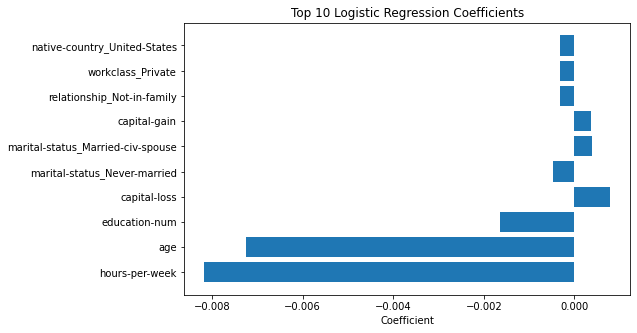

In [14]:
# Interpret your model's outputs 
# YOUR CODE HERE

coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_model.coef_[0]
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

print(coefficients.head(10))

top10 = coefficients.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10['Feature'], top10['Coefficient'])
plt.title("Top 10 Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.show()

### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

1. I chose the Logistic Regression model because it is a good choice for binary classification problems like predicting whether someone's income is above or below $50K. It also trained quickly and achieved good accuracy on this dataset.

2. Through the model selection process, I learned that different hyperparameter values can affect a model's performance. Using GridSearchCV helped me find the best configuration instead of relying on the default settings.

3. The model coefficients show which features have the greatest influence on the prediction. Features such as hours worked per week, age, and education level had some of the strongest effects, meaning they play an important role in predicting income.

4. Since the model is only about 80% accurate, some predictions will be incorrect. If this model were used to make decisions about loans, employment, or government assistance, incorrect predictions could negatively affect people. There are also fairness concerns because factors such as age, sex, race, or marital status may introduce bias into the model.

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [15]:
# Scale your data for the neural network

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [16]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
# YOUR CODE HERE
nn_model.add(Dense(units=64, activation='relu', input_shape=(n_features,)))

# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: How many layers? How many units? What activation function?
# Add a comment explaining your choices.

# I used ReLU for the hidden layers because it trains efficiently.
# The hidden layers use 32 and 16 units to balance model complexity and training time.

# YOUR CODE HERE

nn_model.add(Dense(units=32, activation='relu'))

nn_model.add(Dense(units=16, activation='relu'))

# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
# YOUR CODE HERE
nn_model.add(Dense(units=1, activation='sigmoid'))

# Print a summary of your model
nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 64)                6464      
_________________________________________________________________
dense_1 (Dense)              (None, 32)                2080      
_________________________________________________________________
dense_2 (Dense)              (None, 16)                528       
_________________________________________________________________
dense_3 (Dense)              (None, 1)                 17        
Total params: 9,089
Trainable params: 9,089
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [17]:
# Decision: What learning rate will you use? Add a comment explaining your decision.
# I chose 0.01 because it is a common learning rate that won't make updates too large.

sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01)

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [18]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [19]:
# YOUR CODE HERE
nn_model.compile(
    optimizer=sgd_optimizer,
    loss=loss_fn,
    metrics=['accuracy']
)

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [20]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [21]:
# Decision: How many epochs? Add a comment.

t0 = time.time() # start time

num_epochs = 10 
# I chose 10 epochs to give the model enough opportunities to learn while monitoring the validation performance for signs of overfitting.

# Convert labels to numbers for Keras
y_train_nn = y_train.map({'<=50K': 0, '>50K': 1}).astype('float32')
y_test_nn = y_test.map({'<=50K': 0, '>50K': 1}).astype('float32')

history = nn_model.fit(
    X_train_scaled,
    y_train_nn,
    epochs=num_epochs,
    validation_split=0.2,
    verbose=1
)

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch 1/10
546/546 [==============================] - 3s 4ms/step - loss: 0.4750 - accuracy: 0.7862 - val_loss: 0.3781 - val_accuracy: 0.8304
Epoch 2/10
546/546 [==============================] - 2s 3ms/step - loss: 0.3524 - accuracy: 0.8420 - val_loss: 0.3436 - val_accuracy: 0.8377
Epoch 3/10
546/546 [==============================] - 2s 3ms/step - loss: 0.3273 - accuracy: 0.8507 - val_loss: 0.3324 - val_accuracy: 0.8439
Epoch 4/10
546/546 [==============================] - 1s 3ms/step - loss: 0.3177 - accuracy: 0.8537 - val_loss: 0.3307 - val_accuracy: 0.8439
Epoch 5/10
546/546 [==============================] - 2s 3ms/step - loss: 0.3122 - accuracy: 0.8563 - val_loss: 0.3269 - val_accuracy: 0.8460
Epoch 6/10
546/546 [==============================] - 2s 3ms/step - loss: 0.3082 - accuracy: 0.8575 - val_loss: 0.3214 - val_accuracy: 0.8515
Epoch 7/10
546/546 [==============================] - 2s 4ms/step - loss: 0.3056 - accuracy: 0.8585 - val_loss: 0.3222 - val_accuracy: 0.8515
Epoch 

### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



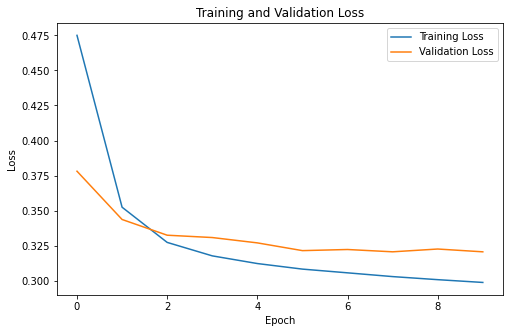

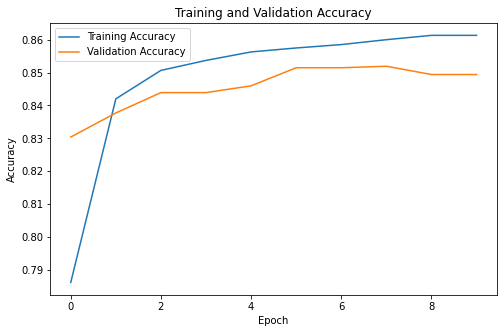

In [22]:
# Plot training loss and validation loss over epochs
# YOUR CODE HERE
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training accuracy and validation accuracy over epochs
# YOUR CODE HERE
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [23]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

# YOUR CODE HERE

# Generate predictions
nn_probabilities = nn_model.predict(X_test_scaled)

# Convert probabilities to 0 or 1
nn_predictions = (nn_probabilities >= 0.5).astype(int).flatten()

In [24]:
# Compute accuracy and F1 score for the neural network and print the results

# YOUR CODE HERE
nn_accuracy = accuracy_score(y_test_nn, nn_predictions)
nn_f1 = f1_score(y_test_nn, nn_predictions)

print("Neural Network Accuracy:", nn_accuracy)
print("Neural Network F1:", nn_f1)

Neural Network Accuracy: 0.8433835845896147
Neural Network F1: 0.6540596094552928


#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

1. I added 32 and 16 to the hidden layers portion to allow for enough complexity to train the model accurately. I used 10 epochs to balance speed and allow it enough time to train. For the activation function, I used relu for hidden layers to grow the complexity and used sigmoid for the output layer so the function could slowly converge. I used a learning rate of 0.01 so that it learns fast enough without sacrificing accuracy. 
2. My training curves tell me that after the first few epochs, the training and validation accuracy are the same. I do not see signs of overfitting as there is a slight difference between the training and validation accuracy.
3. The F1 Score was 0.654 and the accuracy was around 0.843. This is a fairly accurate model. "The results were not surprising because they were consistent with the training and validation curves."

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [26]:
# Build a side-by-side comparison of your two models using the metric variables
# you created. For example:
#
results = pd.DataFrame({
     'Metric': ['Accuracy', 'F1 Score'],
     'Logistic Regression': [accuracy, f1],
     'Neural Network': [nn_accuracy, nn_f1]
 })
print(results.to_string(index=False))

   Metric  Logistic Regression  Neural Network
 Accuracy             0.800205        0.843384
 F1 Score             0.379300        0.654060


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.

I used ChatGPT throughout the capstone, mainly for debugging and reviewing machine learning concepts. I also used it to suggest functions or libraries that could be useful for different tasks, which helped refresh concepts I had learned earlier in the course.

2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.

The data preparation stage required the most effort. There were several possible preprocessing techniques, and it was challenging to decide which ones were appropriate for the dataset. I reviewed the techniques covered in the course materials and used ChatGPT to better understand the available options. I decided to use one-hot encoding for the categorical features and fill in missing values because these are common preprocessing techniques and fit the needs of this dataset.

3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?

To verify that my work was correct, I checked for errors in the code, reviewed the outputs after each step, and made sure they matched what I expected. When I encountered an error, I used the error messages along with ChatGPT to help identify the cause, then verified that the solution produced the expected results.

4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

I would start the capstone earlier next time so I would have more time to experiment with different approaches and review my work. While AI was helpful for debugging and reviewing concepts, having more time would have allowed me to rely more on my own experimentation before using AI.


<Double click this Markdown cell to make it editable, and record your answers here.>